# Lagos Apartment Price Prediction

## Project Overview
In this project, I build a machine learning model that predicts apartment prices in **Lagos, Nigeria**. I progress from a simple single-feature linear regression to a full multi-feature pipeline using real scraped property data.

**Project involves:**
- Data wrangling with a reusable `wrangle()` function
- Exploratory data analysis and visualization
- Linear regression, Ridge regression
- Feature encoding (OneHotEncoder) and imputation (SimpleImputer)
- Sklearn Pipelines
- Neighborhood centroid geocoding (engineering lat/lon form town names)
- Interactive prediction dashboard with ipywidgets

**Target variable:** `price` (in Nigerian Naira)

**Dataset:** Nigeria Houses and Prices - Kaggle (https://www.kaggle.com/datasets/abdullahiyunus/nigeria-houses-and-prices-dataset)

## 1. Predicting Price with Property Size

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

### Prepare Data

In [53]:
def wrangle(filepath):
    df = pd.read_csv(filepath)
    
    # Subset to Lagos only
    mask_lagos = df["state"] == "Lagos"
    # Subset to Flats/apartments only
    mask_apt = df["title"] == "Block of Flats"
    # Subset to properties priced below ₦150,000,000 (to focus on mid-market)
    mask_price = df["price"] < 150_000_000
    
    df = df[mask_lagos & mask_apt & mask_price]

    # Remove bedroom outliers
    low, high = df["bedrooms"].quantile([0.1, 0.9])
    mask_bed = df["bedrooms"].between(low, high)
    df = df[mask_bed]
    
    # -------------------------------------------------------
    # Neighborhood centroid geocoding
    # Maps each Lagos town to its approximate GPS coordinates.
    # -------------------------------------------------------
    town_coords = {
        'Agbara-Igbesa':        (6.5120,  2.9560),
        'Agege':                (6.6167,  3.3333),
        'Ajah':                 (6.4698,  3.5852),
        'Alimosho':             (6.6117,  3.2849),
        'Amuwo Odofin':         (6.4634,  3.3166),
        'Apapa':                (6.4490,  3.3594),
        'Ayobo':                (6.6200,  3.2600),
        'Badagry':              (6.4148,  2.8845),
        'Egbe':                 (6.5700,  3.2800),
        'Ejigbo':               (6.5356,  3.3133),
        'Eko Atlantic City':    (6.4100,  3.4100),
        'Epe':                  (6.5864,  3.9839),
        'Gbagada':              (6.5500,  3.3833),
        'Ibeju':                (6.4500,  3.7200),
        'Ibeju Lekki':          (6.4350,  3.7000),
        'Idimu':                (6.5667,  3.2500),
        'Ifako-Ijaiye':         (6.6381,  3.3100),
        'Ijaiye':               (6.6300,  3.3000),
        'Ijede':                (6.6500,  3.5800),
        'Ijesha':               (6.5100,  3.3700),
        'Ikeja':                (6.5958,  3.3396),
        'Ikorodu':              (6.6194,  3.5060),
        'Ikotun':               (6.5389,  3.2861),
        'Ikoyi':                (6.4550,  3.4340),
        'Ilupeju':              (6.5600,  3.3600),
        'Imota':                (6.6700,  3.6800),
        'Ipaja':                (6.5900,  3.2500),
        'Isheri':               (6.6500,  3.3500),
        'Isheri North':         (6.6600,  3.3600),
        'Isolo':                (6.5250,  3.3300),
        'Ketu':                 (6.5900,  3.3900),
        'Kosofe':               (6.5800,  3.4000),
        'Lagos Island':         (6.4550,  3.4000),
        'Lekki':                (6.4698,  3.5852),
        'Magodo':               (6.6048,  3.3734),
        'Maryland':             (6.5667,  3.3500),
        'Mushin':               (6.5333,  3.3500),
        'Ogudu':                (6.5700,  3.3900),
        'Ojo':                  (6.4700,  3.2150),
        'Ojodu':                (6.6250,  3.3600),
        'Ojota':                (6.5800,  3.3900),
        'Oke-Odo':              (6.6050,  3.2800),
        'Orile':                (6.4800,  3.3200),
        'Oshodi':               (6.5567,  3.3350),
        'Shomolu':              (6.5400,  3.3900),
        'Surulere':             (6.4969,  3.3553),
        'Victoria Island (VI)': (6.4281,  3.4219),
        'Yaba':                 (6.5050,  3.3762),
    }
    
    df['lat'] = df['town'].map(lambda x: town_coords.get(x, (None, None))[0])
    df['lon'] = df['town'].map(lambda x: town_coords.get(x, (None, None))[1])
    
    # Drop rows where we have no coordinate mapping
    df = df.dropna(subset=['lat', 'lon'])

    # Rename town to neighborhood
    df = df.rename(columns={'town': 'neighborhood'})

    df.drop(columns=['title', 'state'], inplace=True, errors='ignore')
    
    return df

df = wrangle('data/nigeria_houses.csv')
print('df shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

df shape: (769, 8)
Columns: ['bedrooms', 'bathrooms', 'toilets', 'parking_space', 'neighborhood', 'price', 'lat', 'lon']


,bedrooms,bathrooms,toilets,parking_space,neighborhood,price,lat,lon
42,2.0,2.0,3.0,2.0,Lekki,30000000.0,6.4698,3.5852
46,3.0,3.0,4.0,4.0,Lekki,25500000.0,6.4698,3.5852
83,2.0,5.0,5.0,4.0,Ikorodu,22500000.0,6.6194,3.5060
110,3.0,5.0,5.0,4.0,Magodo,55000000.0,6.6048,3.3734
182,3.0,3.0,4.0,4.0,Ejigbo,55000000.0,6.5356,3.3133


In [3]:
# Explore data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  float64
 1   bathrooms      24326 non-null  float64
 2   toilets        24326 non-null  float64
 3   parking_space  24326 non-null  float64
 4   title          24326 non-null  object 
 5   town           24326 non-null  object 
 6   state          24326 non-null  object 
 7   price          24326 non-null  float64
dtypes: float64(5), object(3)
memory usage: 1.5+ MB


In [5]:
# Explore unique property types and states
print("Property types:\n", df["title"].value_counts())
print("\nStates:\n", df["state"].value_counts())

Property types:
 title
Detached Duplex           13992
Terraced Duplexes          3237
Semi Detached Duplex       2615
Detached Bungalow          2108
Block of Flats             1745
Semi Detached Bungalow      452
Terraced Bungalow           177
Name: count, dtype: int64

States:
 state
Lagos          18445
Abuja           3524
Ogun             637
Oyo              477
Rivers           444
Imo              246
Anambara         145
Enugu            128
Edo              100
Delta             63
Akwa Ibom         25
Kaduna            23
Osun              12
Ekiti              9
Abia               9
Nasarawa           9
Kwara              9
Kogi               8
Cross River        2
Plateau            2
Kano               2
Katsina            2
Bayelsa            2
Borno              2
Niger              1
Name: count, dtype: int64


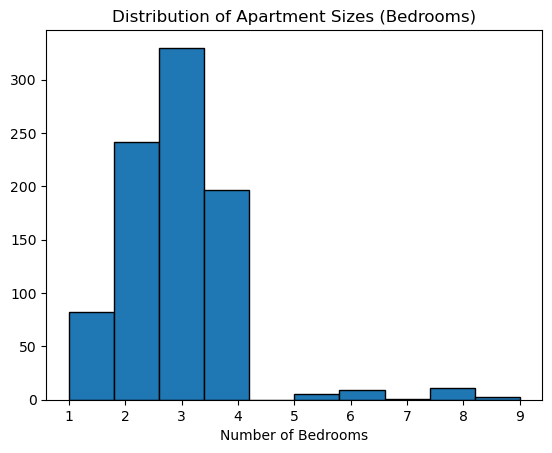

count    880.000000
mean       2.892045
std        1.195719
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        9.000000
Name: bedrooms, dtype: float64

In [7]:
# Explore apartment sizes
plt.hist(df["bedrooms"], bins=10, edgecolor="black")
plt.xlabel("Number of Bedrooms")
plt.title("Distribution of Apartment Sizes (Bedrooms)")
plt.show()

df["bedrooms"].describe()

In [9]:
# Remove bedroom outliers
low, high = df["bedrooms"].quantile([0.1, 0.9])
print(f"Keeping bedrooms between {low} and {high}")

Keeping bedrooms between 2.0 and 4.0


#### Scatter: Price vs Bedrooms

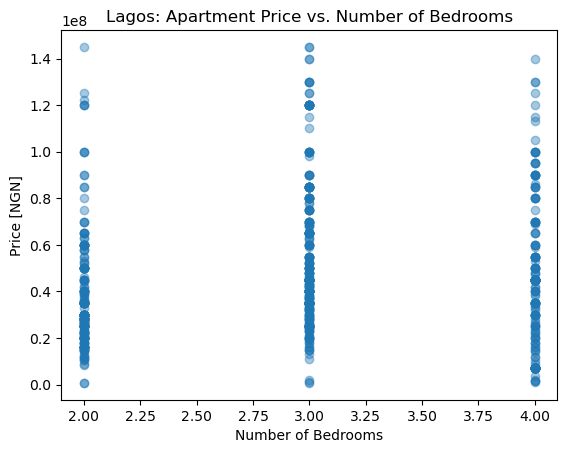

In [11]:
plt.scatter(x=df["bedrooms"], y=df["price"], alpha=0.4)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price [NGN]")
plt.title("Lagos: Apartment Price vs. Number of Bedrooms")
plt.show()

#### Split: feature matrix and target vector

In [12]:
features = ["bedrooms"]
target = "price"

X_train = df[features]
y_train = df[target]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (769, 1)
y_train shape: (769,)


#### Baseline model

In [13]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)

mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
print("Mean apartment price: ₦{:,.0f}".format(y_mean))
print("Baseline MAE: ₦{:,.0f}".format(mae_baseline))

Mean apartment price: ₦46,068,713
Baseline MAE: ₦21,775,839


#### Baseline plot

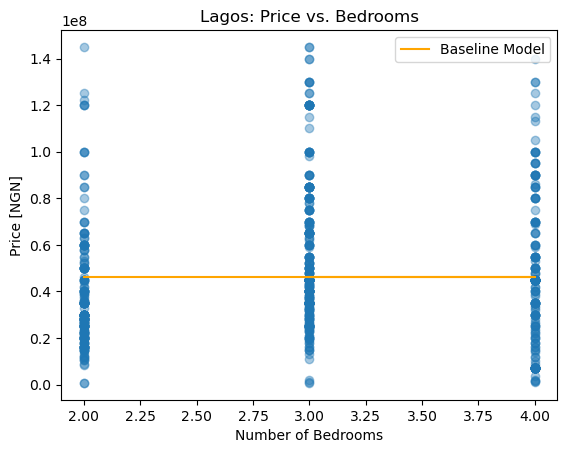

In [14]:
plt.scatter(X_train, y_train, alpha=0.4)
plt.plot(X_train, y_pred_baseline, color="orange", label="Baseline Model")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price [NGN]")
plt.title("Lagos: Price vs. Bedrooms")
plt.legend()
plt.show()

#### Linear regression model

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
check_is_fitted(model)
print("Model trained successfully.")

Model trained successfully.


In [16]:
# Evaluate on training data
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE: ₦{:,.0f}".format(mae_training))

Training MAE: ₦21,509,810


#### Communicate: equation + plot

apartment_price = 31845101.17 + 4835524.84 * bedrooms


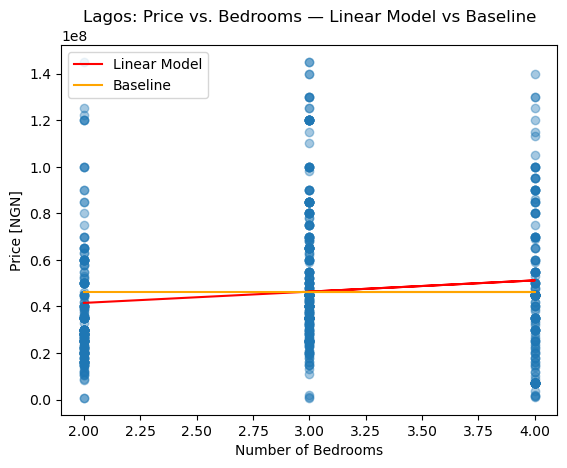

In [17]:
intercept = round(model.intercept_, 2)
coefficient = round(model.coef_[0], 2)

print(f"apartment_price = {intercept} + {coefficient} * bedrooms")

plt.scatter(X_train.values, y_train, alpha=0.4)
plt.plot(X_train.values, model.predict(X_train), color="red", label="Linear Model")
plt.plot(X_train.values, y_pred_baseline, color="orange", label="Baseline")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price [NGN]")
plt.title("Lagos: Price vs. Bedrooms — Linear Model vs Baseline")
plt.legend()
plt.show()

So far, the simplest possible predictive model - one that uses only the number of bedrooms to estimate apartment price in Lagos is built and tested. The baseline model, which blindly predicts the mean price for every apartment, gave a reference point to beat. The linear regression model improved on that baseline, confirming that bedroom count carries real price signal. However, the improvement was modest, which is expected - a single feature like bedrooms is a rough proxy for value. It tells us nothing about where in Lagos the apartment sits, which in a city as economically varied as Lagos, matters enormously.
This limitation is the motivation for the next section, where geographic location is used as a feature for the model.

## 2. Predicting Price with Property location (lat & lon)

In [20]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline

### Prepare Data - Engineering Lat/Lon from Town Names
The Nigeria Houses dataset does not contain raw latitude/longitude columns. And the standard data engineering solution is to map each location name to its known centroid coordinates. Thus, a lookup table of approximate GPS centroids for every Lagos town in the dataset is built and used to create lat and lon columns inside the `wrangle()` function.

In [21]:
# First, let's see all unique towns in the Lagos subset
temp_df = pd.read_csv('data/nigeria_houses.csv')
lagos_towns = temp_df[temp_df['state'] == 'Lagos']['town'].unique()
print(f'Total unique towns in Lagos: {len(lagos_towns)}')
print(sorted(lagos_towns))

Total unique towns in Lagos: 48
['Agbara-Igbesa', 'Agege', 'Ajah', 'Alimosho', 'Amuwo Odofin', 'Apapa', 'Ayobo', 'Badagry', 'Egbe', 'Ejigbo', 'Eko Atlantic City', 'Epe', 'Gbagada', 'Ibeju', 'Ibeju Lekki', 'Idimu', 'Ifako-Ijaiye', 'Ijaiye', 'Ijede', 'Ijesha', 'Ikeja', 'Ikorodu', 'Ikotun', 'Ikoyi', 'Ilupeju', 'Imota', 'Ipaja', 'Isheri', 'Isheri North', 'Isolo', 'Ketu', 'Kosofe', 'Lagos Island', 'Lekki', 'Magodo', 'Maryland', 'Mushin', 'Ogudu', 'Ojo', 'Ojodu', 'Ojota', 'Oke-Odo', 'Orile', 'Oshodi', 'Shomolu', 'Surulere', 'Victoria Island (VI)', 'Yaba']


### Explore

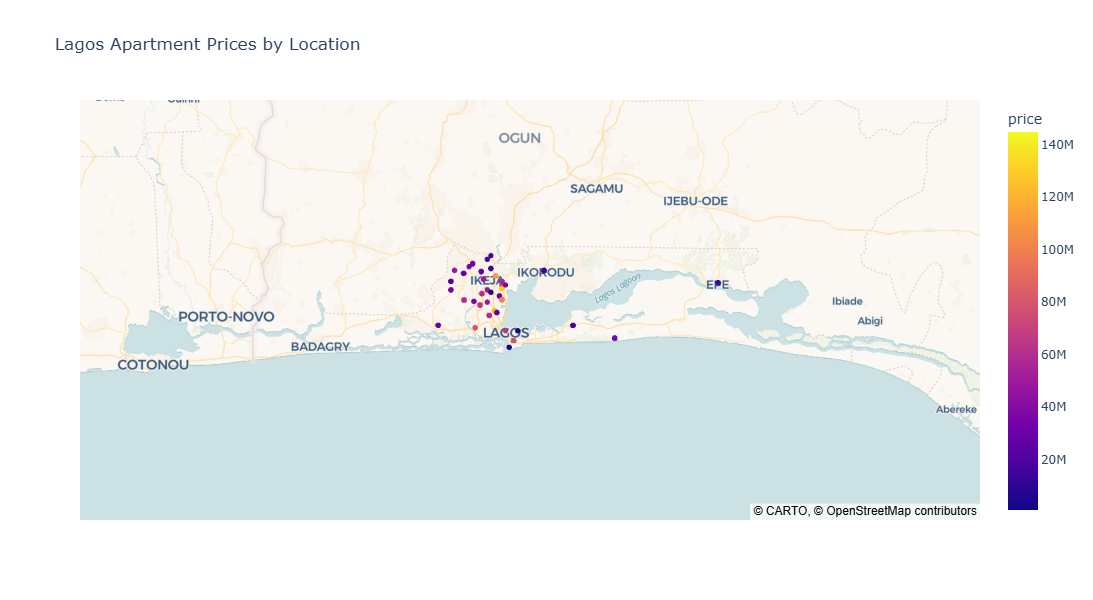

In [25]:
# Mapbox scatter plot: price by geographic location
fig = px.scatter_map(
    df,
    lat='lat',
    lon='lon',
    color='price',
    hover_data=['price', 'bedrooms', 'town'],
    width=700,
    height=600,
    title='Lagos Apartment Prices by Location'
)
fig.update_layout(mapbox_style='open-street-map')
fig.show()

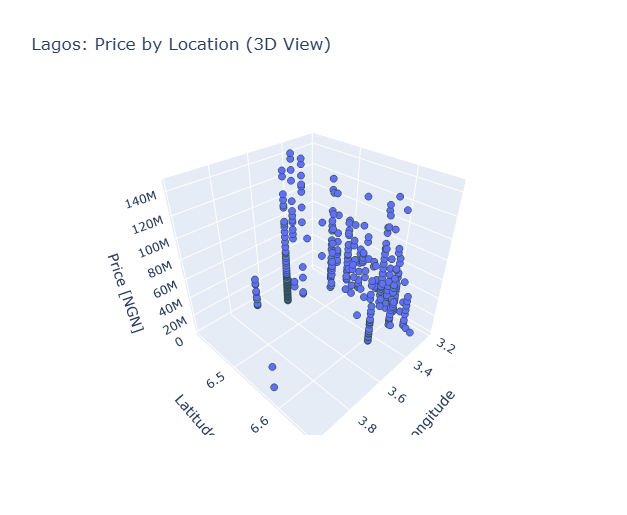

In [26]:
# 3D scatter: price as height, lat/lon as x-y plane
fig = px.scatter_3d(
    df,
    x='lon',
    y='lat',
    z='price',
    labels={'lon': 'Longitude', 'lat': 'Latitude', 'price': 'Price [NGN]'},
    width=700,
    height=500,
    title='Lagos: Price by Location (3D View)'
)
fig.update_traces(
    marker={'size': 4, 'line': {'width': 2, 'color': 'DarkSlateGrey'}},
    selector={'mode': 'markers'}
)
fig.show()

### Split

In [27]:
features = ['lon', 'lat']
target = 'price'

X_train = df[features]
y_train = df[target]

print('X_train shape:', X_train.shape)

X_train shape: (769, 2)


### Baseline model

In [28]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print('Mean apartment price: ₦{:,.0f}'.format(y_mean))
print('Baseline MAE:         ₦{:,.0f}'.format(mae_baseline))

Mean apartment price: ₦46,068,713
Baseline MAE:         ₦21,775,839


### Iterate model
Since engineered lat/lon values are clean (no missing values after the `dropna`), the `SimpleImputer` is a safeguard that also makes the pipeline robust to future data variations. Thus, it is combined with `LinearRegression` into a single Pipeline.

In [29]:
# Check for missing values in features before building pipeline
print('Missing values in X_train:')
print(X_train.isnull().sum())

Missing values in X_train:
lon    0
lat    0
dtype: int64


In [30]:
model = make_pipeline(
    SimpleImputer(),
    LinearRegression()
)
model.fit(X_train, y_train)
check_is_fitted(model['linearregression'])
print('Pipeline trained.')

Pipeline trained.


### Evaluate

In [31]:
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)

print('Baseline MAE: ₦{:,.0f}'.format(mae_baseline))
print('Training MAE: ₦{:,.0f}'.format(mae_training))

Baseline MAE: ₦21,775,839
Training MAE: ₦21,257,227


### Communicate Results

In [32]:
intercept = model.named_steps['linearregression'].intercept_.round()
coefficients = model.named_steps['linearregression'].coef_.round()

print(f'price = {intercept} + ({coefficients[0]} * longitude) + ({coefficients[1]} * latitude)')

price = 508719172.0 + (-47539149.0 * longitude) + (-45734996.0 * latitude)


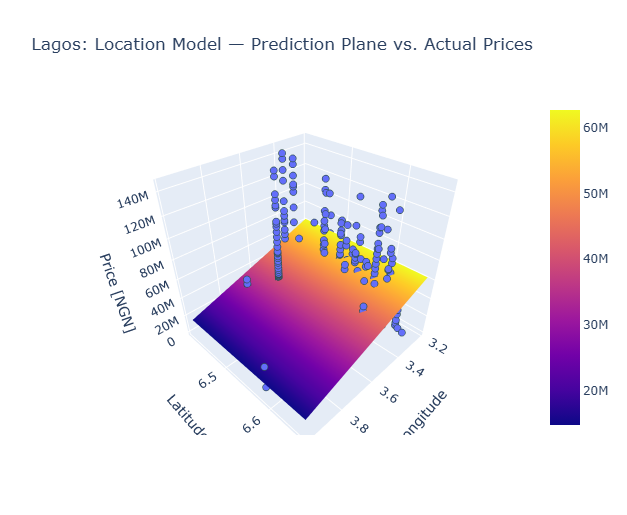

In [33]:
# 3D scatter with model prediction plane
fig = px.scatter_3d(
    df, x='lon', y='lat', z='price',
    labels={'lon': 'Longitude', 'lat': 'Latitude', 'price': 'Price [NGN]'},
    width=700, height=500,
    title='Lagos: Location Model — Prediction Plane vs. Actual Prices'
)

x_plane = np.linspace(df['lon'].min(), df['lon'].max(), 10)
y_plane = np.linspace(df['lat'].min(), df['lat'].max(), 10)
xx, yy = np.meshgrid(x_plane, y_plane)

z_plane = model.predict(pd.DataFrame({'lon': x_plane, 'lat': y_plane}))
zz = np.tile(z_plane, (10, 1))

fig.add_trace(go.Surface(x=xx, y=yy, z=zz))
fig.update_traces(
    marker={'size': 4, 'line': {'width': 2, 'color': 'DarkSlateGrey'}},
    selector={'mode': 'markers'}
)
fig.show()

By replacing bedroom count with latitude and longitude, I explored whether geographic location alone could predict apartment prices in Lagos. The results are revealing - location does carry price signal, but the relationship is more complex than a flat plane can capture. Lagos is not a city where price increases smoothly in one direction; it has concentrated clusters of high-value areas like Lekki, Victoria Island, and Ikoyi, surrounded by more affordable neighborhoods in all directions. A key engineering decision in this section was constructing lat/lon coordinates from town names using a centroid lookup table - a standard real-world technique for datasets that record location as names rather than coordinates. This section also introduced the sklearn Pipeline, a critical tool for keeping transformation and modeling steps clean and reproducible. The flat plane the model draws through 3D space cannot capture these non-linear geographic clusters, which motivates using neighborhood as a categorical feature in the next section.

## 3. Predicting Price with Neighborhood

In [34]:
from category_encoders import OneHotEncoder
from sklearn.linear_model import Ridge
import seaborn as sns

### Prepare Data

In the `wrangle()` function, we rename `town` to `neighborhood` to match standard real estate ML terminology and make our column naming consistent.

### Split

In [37]:
features = ['neighborhood']
target = 'price'

X_train = df[features]
y_train = df[target]

### Baseline model

In [38]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print('Mean apartment price: ₦{:,.0f}'.format(y_mean))
print('Baseline MAE: ₦{:,.0f}'.format(mae_baseline))

Mean apartment price: ₦46,068,713
Baseline MAE: ₦21,775,839


### Iterate model
Neighborhood is a categorical (string) feature. Linear regression requires numerical input, so we must encode it first. `OneHotEncoder` creates a separate binary column for each neighborhood - the model then learns a price adjustment for each one.

We first explore how the encoder works manually, then fold it into a pipeline.

In [39]:
# Explore OneHotEncoder manually before building pipeline
ohe = OneHotEncoder(use_cat_names=True)
ohe.fit(X_train)
XT_train = ohe.transform(X_train)
print('Encoded shape:', XT_train.shape)
XT_train.head()

Encoded shape: (769, 39)


,neighborhood_Lekki,neighborhood_Ikorodu,neighborhood_Magodo,neighborhood_Ejigbo,neighborhood_Ajah,neighborhood_Victoria Island (VI),neighborhood_Ikoyi,neighborhood_Surulere,neighborhood_Ifako-Ijaiye,neighborhood_Yaba,...,neighborhood_Epe,neighborhood_Mushin,neighborhood_Ilupeju,neighborhood_Isheri,neighborhood_Kosofe,neighborhood_Amuwo Odofin,neighborhood_Maryland,neighborhood_Eko Atlantic City,neighborhood_Ijesha,neighborhood_Lagos Island
42,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
46,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
83,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
110,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
182,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
# Build pipeline with OneHotEncoder + Ridge
# Ridge adds regularization to prevent overfitting across many neighborhood features
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    Ridge()
)
model.fit(X_train, y_train)
check_is_fitted(model[-1])
print('Pipeline trained.')

Pipeline trained.


### Evaluate

In [41]:
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)

print('Baseline MAE: ₦{:,.0f}'.format(mae_baseline))
print('Training MAE: ₦{:,.0f}'.format(mae_training))

Baseline MAE: ₦21,775,839
Training MAE: ₦18,955,584


### `Ridge()` vs `LinearRegression()` 
Let's replace `Ridge()` model with `LinearRegression()` to see the effect of **overfitting**.

In [43]:
model_2 = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LinearRegression()
)
model_2.fit(X_train, y_train)
check_is_fitted(model_2[-1])
print('Pipeline trained.')

y_pred_training = model_2.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)

print('Baseline MAE: ₦{:,.0f}'.format(mae_baseline))
print('Training MAE: ₦{:,.0f}'.format(mae_training))

Pipeline trained.
Baseline MAE: ₦21,775,839
Training MAE: ₦18,726,776


The training MAE with `LinearRegression` is lower compared to the one gotten when using `Rigde`. That is due to overfitting - the model memorizes the training data rather than learning generalization patterns. `Ridge` penalizes large coefficients, producing a more honest model that generalizes to unseen data.

### Communicate Results

In [44]:
intercept = model.named_steps['ridge'].intercept_
coefficients = model.named_steps['ridge'].coef_
feature_names = model.named_steps['onehotencoder'].get_feature_names()

print('Number of coefficients:', len(coefficients))
feat_imp = pd.Series(coefficients, index=feature_names)
feat_imp.head()

Number of coefficients: 39


neighborhood_Lekki     -4.020258e+06
neighborhood_Ikorodu   -1.996039e+07
neighborhood_Magodo     3.591905e+07
neighborhood_Ejigbo    -2.874779e+06
neighborhood_Ajah      -1.332251e+07
dtype: float64

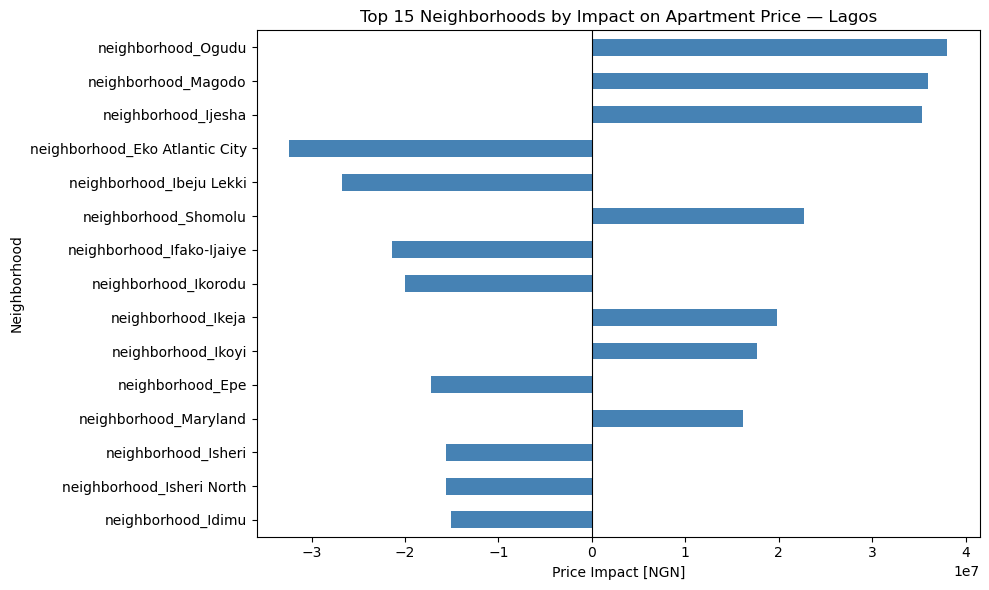

In [45]:
# Top 15 neighborhoods by absolute impact on price
feat_imp.sort_values(key=abs).tail(15).plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.xlabel('Price Impact [NGN]')
plt.ylabel('Neighborhood')
plt.title('Top 15 Neighborhoods by Impact on Apartment Price — Lagos')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Encoding neighborhood as a categorical feature using `OneHotEncoder` gave the model a much richer understanding of location than raw coordinates could provide. Each neighborhood became its own feature, and the model learned a separate price adjustment for each one. The feature importance bar chart reveals some surprising patterns in Lagos real estate. Ogudu, Magodo, and Ijesha emerge as the strongest positive price predictors, while established luxury areas like Eko Atlantic City and Ibeju Lekki show negative coefficients because the ₦150,000,000 price ceiling removed most of the ultra-luxury listings in those areas, leaving only a small, unrepresentative sample that the Ridge model cannot reliably learn from.
This section also explored overfitting: with dozens of neighborhood features, a plain `LinearRegression` model fits the training data too closely and loses its ability to generalize. Switching to `Ridge` regression introduced regularization - a mathematical penalty on large coefficients - producing a more honest and generalizable model.

## 4. Building a Comprehensive Price Prediction Model

In [46]:
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact

### Prepare Data - Full Wrangle Function

Before combining all features, we audit the dataset for four common pitfalls that can silently harm model performance:
1. **High-null columns** - more than 50% missing, not worth imputing
2. **Leaky features** - direct proxies of the target (price) that the model wouldn't have at prediction time
3. **Low/high cardinality categoricals** - either useless (one value) or too noisy (unique per row)
4. **Multicollinearity** - features that are strongly correlated with each other

In [47]:
# Audit 1: High-null columns
null_pct = df.isnull().mean() * 100
print("Null percentage per column:")
print(null_pct.sort_values(ascending=False))

Null percentage per column:
bedrooms         0.0
bathrooms        0.0
toilets          0.0
parking_space    0.0
title            0.0
neighborhood     0.0
state            0.0
price            0.0
lat              0.0
lon              0.0
dtype: float64


This dataset has no missing values, but the check is an essential practice.

In [48]:
# Audit 2: Leaky features
# Leaky features are columns derived from or directly encoding the target.
# Common examples: price_per_m2, price_usd, price_per_room.
print("All columns:", df.columns.tolist())

All columns: ['bedrooms', 'bathrooms', 'toilets', 'parking_space', 'title', 'neighborhood', 'state', 'price', 'lat', 'lon']


None of the remaining columns are price proxies.
'bedrooms', 'bathrooms', 'toilets', 'parking_space' are all property attributes known before a sale - legitimate features.

In [49]:
# Audit 3: Cardinality check 
print(df.select_dtypes('object').nunique())

title            1
neighborhood    39
state            1
dtype: int64


After filtering to Lagos apartments only in the `wrangle` function, `title` and `state` columns are left with 1 unique values, `Lagos` and `Block of Flats`. Thus, those 2 columns will be dropped as they have zero variance.

In [50]:
df.drop(columns=['title', 'state'], inplace=True, errors='ignore')
print("\nColumns after cardinality drop:", df.columns.tolist())


Columns after cardinality drop: ['bedrooms', 'bathrooms', 'toilets', 'parking_space', 'neighborhood', 'price', 'lat', 'lon']


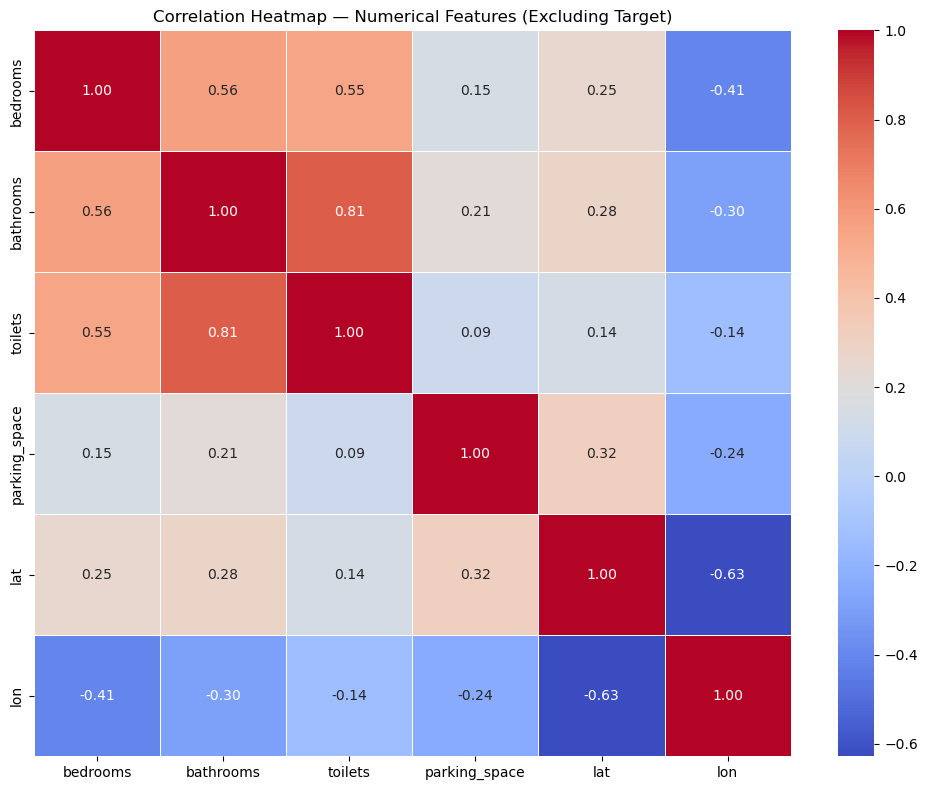

In [51]:
# Audit 4: Multicollinearity check using correlation heatmap
corr = df.select_dtypes('number').drop(columns='price').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features (Excluding Target)')
plt.tight_layout()
plt.show()

Based on the heatmap, no feature pair exceeds the 0.85 threshold. The highest correlation is bathrooms with toilets at 0.81 - notable but not strong enough to justify dropping either feature. Thus, all features will be retained.

In [52]:
print("No multicollinearity issues found. All features retained.")
print("Final columns:", df.columns.tolist())
print("Final shape:  ", df.shape)

No multicollinearity issues found. All features retained.
Final columns: ['bedrooms', 'bathrooms', 'toilets', 'parking_space', 'neighborhood', 'price', 'lat', 'lon']
Final shape:   (769, 8)


The `wrangle()` function can now be updated with the audit results - will include the one that drops the cardinality columns since the other audits has given no significant result for update.

### Split

In [54]:
target = 'price'
features = ['bedrooms', 'bathrooms', 'toilets', 'parking_space', 'lat', 'lon', 'neighborhood']

y_train = df[target]
X_train = df[features]

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

X_train shape: (769, 7)
y_train shape: (769,)


### Baseline model

In [55]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print('Mean apartment price: ₦{:,.0f}'.format(y_mean))
print('Baseline MAE: ₦{:,.0f}'.format(mae_baseline))

Mean apartment price: ₦46,068,713
Baseline MAE: ₦21,775,839


### Build Model - Full Pipeline

The full pipeline combines all three tools:
- `OneHotEncoder` - encodes the categorical `neighborhood` column
- `SimpleImputer` - handles any remaining missing values in numerical features
- `Ridge` - fits the model with regularization to prevent overfitting

In [56]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    Ridge()
)
model.fit(X_train, y_train)
print('Full pipeline trained successfully.')

Full pipeline trained successfully.


### Evaluate

In [57]:
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)

print('Baseline MAE: ₦{:,.0f}'.format(mae_baseline))
print('Training MAE: ₦{:,.0f}'.format(mae_training))
print('Improvement:  ₦{:,.0f}'.format(mae_baseline - mae_training))

Baseline MAE: ₦21,775,839
Training MAE: ₦18,793,186
Improvement:  ₦2,982,653


### Communicate Results - Prediction Function

In [58]:
# Neighborhood centroid lookup for prediction function
TOWN_COORDS = {
    'Agbara-Igbesa': (6.5120,  2.9560), 'Agege': (6.6167,  3.3333),
    'Ajah': (6.4698,  3.5852), 'Alimosho': (6.6117,  3.2849),
    'Amuwo Odofin': (6.4634,  3.3166), 'Apapa': (6.4490,  3.3594),
    'Ayobo': (6.6200,  3.2600), 'Badagry': (6.4148,  2.8845),
    'Egbe': (6.5700,  3.2800), 'Ejigbo': (6.5356,  3.3133),
    'Eko Atlantic City': (6.4100,  3.4100), 'Epe': (6.5864,  3.9839),
    'Gbagada': (6.5500,  3.3833), 'Ibeju': (6.4500,  3.7200),
    'Ibeju Lekki': (6.4350,  3.7000), 'Idimu': (6.5667,  3.2500),
    'Ifako-Ijaiye': (6.6381,  3.3100), 'Ijaiye': (6.6300,  3.3000),
    'Ijede': (6.6500,  3.5800), 'Ijesha': (6.5100,  3.3700),
    'Ikeja': (6.5958,  3.3396), 'Ikorodu': (6.6194,  3.5060),
    'Ikotun': (6.5389,  3.2861), 'Ikoyi': (6.4550,  3.4340),
    'Ilupeju': (6.5600,  3.3600), 'Imota': (6.6700,  3.6800),
    'Ipaja': (6.5900,  3.2500), 'Isheri': (6.6500,  3.3500),
    'Isheri North': (6.6600,  3.3600), 'Isolo': (6.5250,  3.3300),
    'Ketu': (6.5900,  3.3900), 'Kosofe': (6.5800,  3.4000),
    'Lagos Island': (6.4550,  3.4000), 'Lekki': (6.4698,  3.5852),
    'Magodo': (6.6048,  3.3734), 'Maryland': (6.5667,  3.3500),
    'Mushin': (6.5333,  3.3500), 'Ogudu': (6.5700,  3.3900),
    'Ojo': (6.4700,  3.2150), 'Ojodu': (6.6250,  3.3600),
    'Ojota': (6.5800,  3.3900), 'Oke-Odo': (6.6050,  3.2800),
    'Orile': (6.4800,  3.3200), 'Oshodi': (6.5567,  3.3350),
    'Shomolu': (6.5400,  3.3900), 'Surulere': (6.4969,  3.3553),
    'Victoria Island (VI)': (6.4281,  3.4219), 'Yaba': (6.5050,  3.3762),
}

def make_prediction(bedrooms, bathrooms, toilets, parking_space, neighborhood):
    lat, lon = TOWN_COORDS.get(neighborhood, (6.5244, 3.3792))  # fallback to Lagos centre
    data = {
        'bedrooms':      bedrooms,
        'bathrooms':     bathrooms,
        'toilets':       toilets,
        'parking_space': parking_space,
        'lat':           lat,
        'lon':           lon,
        'neighborhood':  neighborhood
    }
    df_input = pd.DataFrame(data, index=[0])
    prediction = model.predict(df_input).round(0)[0]
    return f'Predicted apartment price: ₦{prediction:,.0f}'

# Test
make_prediction(3, 2, 2, 1, 'Lekki')

'Predicted apartment price: ₦42,794,270'

### Communicate Results - Interactive Dashboard

In [59]:
interact(
    make_prediction,
    bedrooms=IntSlider(min=1, max=int(X_train['bedrooms'].max()), value=3),
    bathrooms=IntSlider(min=1, max=int(X_train['bathrooms'].max()), value=2),
    toilets=IntSlider(min=1, max=int(X_train['toilets'].max()), value=2),
    parking_space=IntSlider(min=0, max=int(X_train['parking_space'].max()), value=1),
    neighborhood=Dropdown(
        options=sorted(X_train['neighborhood'].dropna().unique()),
        value='Lekki'
    )
);

interactive(children=(IntSlider(value=3, description='bedrooms', max=4, min=1), IntSlider(value=2, description…

The final model brought together everything built across the previous three sections - bedroom count, bathroom count, engineered geographic coordinates, and neighborhood - into a single unified pipeline. Before combining features, I carefully audited the dataset for four common modeling pitfalls: high-null columns offering more noise than signal, low- and high-cardinality categoricals that confuse the model, leaky features that smuggle in target information, and multicollinear features that introduce redundancy. The correlation heatmap was an essential diagnostic tool here. The full pipeline - `OneHotEncoder`, `SimpleImputer`, `Ridge` - handled categorical encoding, missing value imputation, and regularization in one clean, reproducible object. The interactive widget at the end transformed the model from an abstract mathematical construction into a practical tool that anyone - including non-technical stakeholders - can use to get an instant price estimate for any Lagos apartment.

### Project Conclusion

This project traced the full arc of a supervised machine learning workflow applied to real Lagos apartment price data. Starting from a naive baseline and a single feature, I progressively built toward a robust multi-feature pipeline - each section motivated by the clear shortcomings of the previous model. Along the way I practiced the core skills of applied ML: iterative data wrangling with a reusable `wrangle()` function, exploratory data analysis, feature engineering (including building a geocoding lookup table from scratch), handling missing values, encoding categorical variables, diagnosing and correcting overfitting with Ridge regularization, and deploying a model as an interactive dashboard.